In [1]:
import sys
sys.path.append("../")
sys.path.append("../Modules/")

import analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Modules import plot_morphology

In [2]:
sim_directory = '/home/drfrbc/Neural-Modeling/scripts/2025-03-10-13-45-checking_syn_density_tuning/tuning_Complex_Np5000'

In [3]:
v = analysis.DataReader.read_data(sim_directory, "v")
seg_data = pd.read_csv(os.path.join(sim_directory, "segment_data.csv"))
parameters = analysis.DataReader.load_parameters(sim_directory)
adj_matrix = np.loadtxt(os.path.join(sim_directory, "adj_matrix.txt"))

--No graphics will be displayed.


In [4]:
# post processing equivalent of cell_model.find_nexus_seg
from Modules.adjacency import find_branching_seg_with_most_branching_descendants_in_subset_y
def find_nexus_seg(seg_data, adj_matrix): # TODO: implement for reducing apic to single cable (in this case nexus is not a branching point and will need to use the seg_to_seg mapping)
    apical_segment_indices = []
    y_coords = []
    for i, seg in seg_data.iterrows():
        y_coord = seg.pc_1
        y_coords.append(y_coord)
        if 'apic' in seg.seg:
            apical_segment_indices.append(i)

    nexus_index_in_all_list, _ = find_branching_seg_with_most_branching_descendants_in_subset_y(adj_matrix, apical_segment_indices, y_coords)

    return nexus_index_in_all_list

In [5]:
# start with seg_index and then construct segments_and_data_to_plot
segments_of_interest = {
    'soma': {
        'seg_index': 0,
        },
    'nexus': {
        'seg_index': find_nexus_seg(seg_data, adj_matrix)
        }
}

In [6]:
# show target segment names
for seg_interest_type in segments_of_interest.keys():
    print(f"{seg_interest_type}: {seg_data.iloc[segments_of_interest[seg_interest_type]['seg_index']].seg}")

soma: L5PCtemplate[0].soma[0](0.5)
nexus: L5PCtemplate[0].apic[36](0.989796)


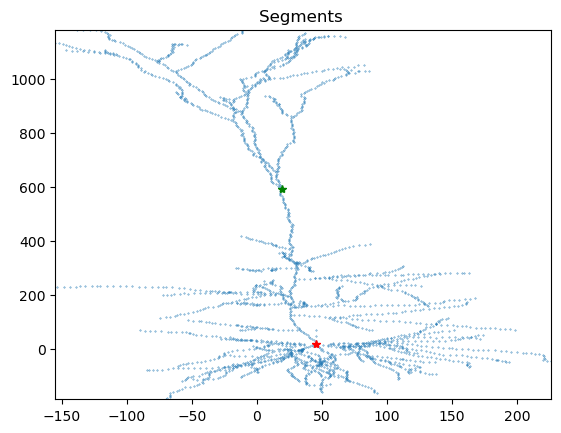

In [7]:
# show target segments
special_indices = [segments_of_interest[seg_name]['seg_index'] for seg_name in segments_of_interest.keys()]
special_colors = ['r*', 'g*', 'b*']
plot_morphology.plot_special_segments(seg_data, special_indices, special_colors, title_suffix="") # probably need to create a 3d version of this.

In [8]:
def find_relatives(seg_id, adj_matrix):
    descendant_seg_ids = np.where(adj_matrix[seg_id, :] == 1)[0]
    ascendant_seg_ids = np.where(adj_matrix[:, seg_id] == 1)[0]
    return descendant_seg_ids, ascendant_seg_ids

for seg_interest_type in segments_of_interest.keys():
    descendent_seg_ids, ascendant_seg_ids = find_relatives(segments_of_interest[seg_interest_type]['seg_index'], adj_matrix)
    segments_of_interest[seg_interest_type]['descendant_ids'] = descendent_seg_ids
    segments_of_interest[seg_interest_type]['descendant_names'] = [seg_data.iloc[seg_id].seg for seg_id in segments_of_interest[seg_interest_type]['descendant_ids']]
    segments_of_interest[seg_interest_type]['ascendant_ids'] = ascendant_seg_ids
    segments_of_interest[seg_interest_type]['ascendant_names'] = [seg_data.iloc[seg_id].seg for seg_id in segments_of_interest[seg_interest_type]['ascendant_ids']]

In [9]:
segments_of_interest

{'soma': {'seg_index': 0,
  'descendant_ids': array([   1,  126,  223,  456,  501,  736,  963,  972, 1023, 2508]),
  'descendant_names': ['L5PCtemplate[0].dend[0](0.1)',
   'L5PCtemplate[0].dend[7](0.1)',
   'L5PCtemplate[0].dend[16](0.166667)',
   'L5PCtemplate[0].dend[39](0.0263158)',
   'L5PCtemplate[0].dend[42](0.166667)',
   'L5PCtemplate[0].dend[63](0.1)',
   'L5PCtemplate[0].dend[78](0.0555556)',
   'L5PCtemplate[0].dend[79](0.166667)',
   'L5PCtemplate[0].apic[0](0.0555556)',
   'L5PCtemplate[0].axon[0](0.166667)'],
  'ascendant_ids': array([], dtype=int64),
  'ascendant_names': []},
 'nexus': {'seg_index': 1475,
  'descendant_ids': array([1476, 1679]),
  'descendant_names': ['L5PCtemplate[0].apic[37](0.00909091)',
   'L5PCtemplate[0].apic[50](0.0384615)'],
  'ascendant_ids': array([1474]),
  'ascendant_names': ['L5PCtemplate[0].apic[36](0.969388)']}}

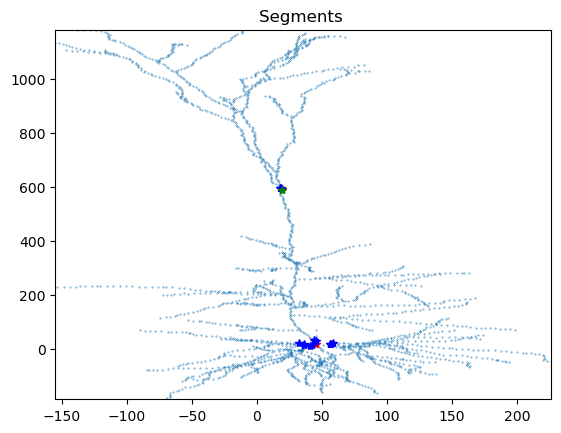

In [10]:
target_color = 'r*'
descendant_color = 'b*'
ascendant_color = 'g*'

descendent_seg_ids = []
ascendent_seg_ids = []

# Target segments
special_indices = [segments_of_interest[seg_name]['seg_index'] for seg_name in segments_of_interest.keys()]
special_colors = [target_color] * len(special_indices)

# Descendants
descendent_seg_ids = np.concatenate([segments_of_interest[seg_name]['descendant_ids'] for seg_name in segments_of_interest.keys()])
special_indices.extend(descendent_seg_ids)
special_colors.extend([descendant_color] * len(descendent_seg_ids))

# Ascendants
ascendent_seg_ids = np.concatenate([segments_of_interest[seg_name]['ascendant_ids'] for seg_name in segments_of_interest.keys()])
special_indices.extend(ascendent_seg_ids)
special_colors.extend([ascendant_color] * len(ascendent_seg_ids))

plot_morphology.plot_special_segments(seg_data, special_indices, special_colors, title_suffix="")

In [11]:
def compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data):
            # axial current between segments from other_seg to this_seg
            # if this_seg is high and other_seg is low then current goes from this_seg to other_seg, and value would be negative.
            return -(v[this_seg_id] - v[other_seg_id]) / (seg_data.loc[this_seg_id, "seg_half_seg_RA"] + seg_data.loc[other_seg_id, "seg_half_seg_RA"])

for seg_interest_type in segments_of_interest.keys():
        this_seg_id = segments_of_interest[seg_interest_type]['seg_index']

        # ascendants (usually toward soma)
        segments_of_interest[seg_interest_type]['ascendant_currents'] = [compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data) for other_seg_id in segments_of_interest[seg_interest_type]['ascendant_ids']]

        # descendants (usually away from soma)
        segments_of_interest[seg_interest_type]['descendant_currents'] = [compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data) for other_seg_id in segments_of_interest[seg_interest_type]['descendant_ids']]


In [12]:
t = np.arange(0, parameters.h_tstop+parameters.h_dt, parameters.h_dt)

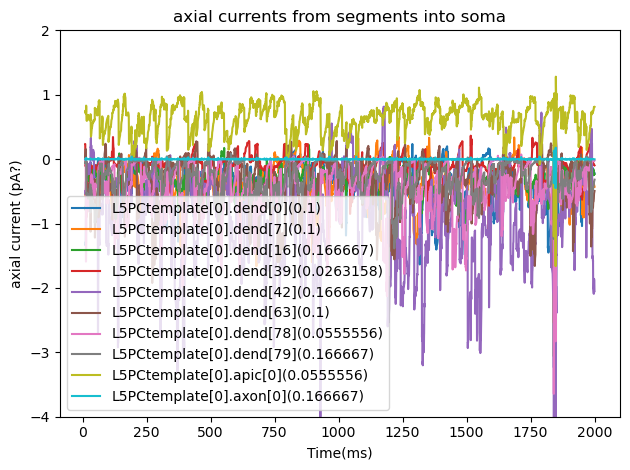

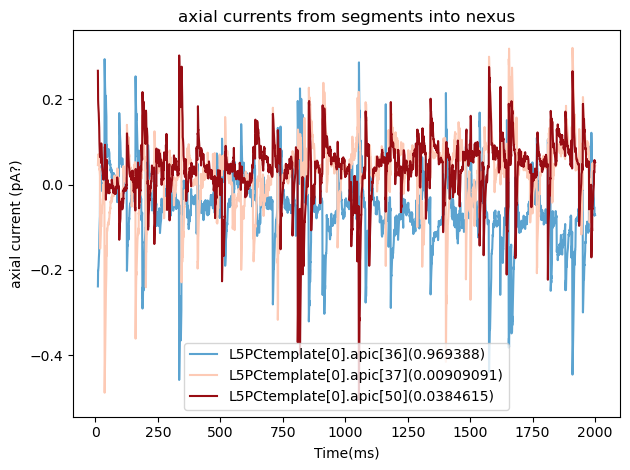

In [13]:
# plot the axial currents axial currents.

t = np.arange(0, parameters.h_tstop+parameters.h_dt, parameters.h_dt)
t=t[100:]
for seg_interest_type, seg_interest_data in segments_of_interest.items():
    # print(f"{seg_interest_type} {seg_interest_data}")
    is_soma = True if seg_interest_type == 'soma' else False
    plt.figure()
    plt.title(f"axial currents from segments into {seg_interest_type}")
    for relative_type in ['ascendant', 'descendant']:
        cmap = plt.cm.Blues if relative_type == 'ascendant' else plt.cm.Reds
        num_segments = len(seg_interest_data[f'{relative_type}_ids'])
        fractions = np.linspace(0.2, 0.9, num_segments) if num_segments > 1 else [0.55] # Generate fractions in the range [0.3, 0.8] to avoid very light colors.
        for i, seg_id in enumerate(seg_interest_data[f'{relative_type}_ids']):
            color = cmap(fractions[i])
            if is_soma:
                plt.plot(t, seg_interest_data[f'{relative_type}_currents'][i][100:], label = seg_interest_data[f'{relative_type}_names'][i]) # can make the lines clearer
                plt.ylim([-4,2])
            else:
                plt.plot(t, seg_interest_data[f'{relative_type}_currents'][i][100:], label = seg_interest_data[f'{relative_type}_names'][i], color=color)
    # plt.xlim(10,)
    plt.xlabel('Time(ms)')
    plt.ylabel('axial current (pA?)')
    plt.legend()
    plt.tight_layout()
    plt.show()

General Notes to know: 

positive is into the segment
negative is out of the segment

red is segments away from the soma, 
blue is segments toward the soma

Soma AC:

Charge is usually flowing from apical trunk into soma into basal dendrites.

Axon doesn't matter.

Nexus AC:

Charge is usually flowing from distal toward soma

Additional Notes:

Can also plot segment currents